# TP 3: Logistic_Regression

**Group 1: I3-AMS-TPB**<br>

**Name: NUON CHANVATHANA**<br>

**ID: e20230118**


Remarks: All models here should be built from scratch.


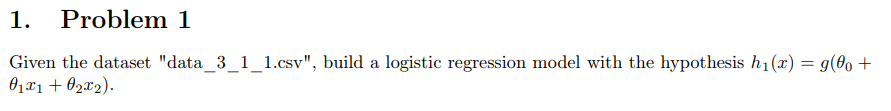

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
df = pd.read_csv('data_3_1_1.csv')
df.head()

,x1,x2,class
0,6.70,6.79,1
1,6.92,3.87,1
2,7.87,5.36,1
3,2.93,6.91,0
4,6.67,4.92,1


In [131]:
X_train = df[['x1', 'x2']].values
y_train = df['class'].values
m, n = X_train.shape
print(f"Number of training examples: {m}")

Number of training examples: 100


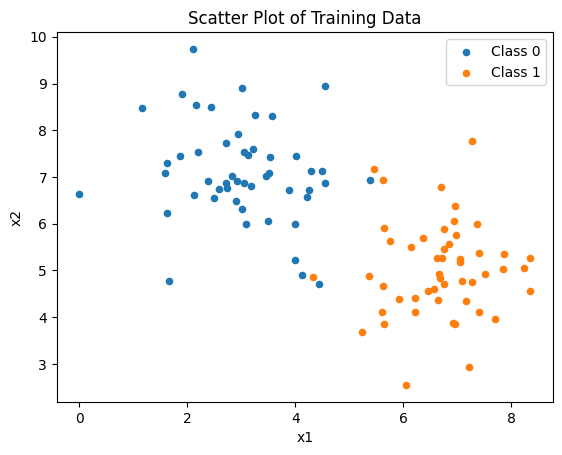

In [132]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [133]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cost function
def cost_function(X, y, w, b):
    m = X.shape[0]
    cost_sum = 0
    epsilon = 1e-15

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, epsilon, 1 - epsilon)

        cost_sum += -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)

    return (1/m) * cost_sum

#gradient function
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i][j]


    grad_w = (1/m) * grad_w
    grad_b = (1/m) * grad_b
    return grad_w, grad_b

#gradient descent function
def gradient_descent(X, y, alpha, iterations):
    m,n = X.shape
    w = np.zeros(n)
    b = 0

    for it in range(iterations):
        grad_w, grad_b = gradient_function(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

        if it % 100 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iteration {it}: Cost {cost_function(X, y, w, b)}")

    return w, b
                      

In [134]:
def predict(X, w, b):
    m = X.shape[0]
    preds = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        preds[i] = 1 if g >= 0.5 else 0

    return preds


In [135]:
def get_confusion_matrix(y_true, y_pred):
    # 1. Identify all unique classes and sort them for consistent indexing
    classes = sorted(list(set(y_true) | set(y_pred)))
    class_to_idx = {val: i for i, val in enumerate(classes)}
    size = len(classes)
    
    # 2. Initialize an empty (zeroed) square matrix
    matrix = [[0] * size for _ in range(size)]
    
    # 3. Fill the matrix by iterating through both lists simultaneously
    for actual, predicted in zip(y_true, y_pred):
        row = class_to_idx[actual]
        col = class_to_idx[predicted]
        matrix[row][col] += 1
        
    return matrix, classes

In [136]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, num_iterations)

predictions = predict(X_train, final_w, final_b)

accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6821805774484099
Iteration 100: Cost 0.2766995245505756
Iteration 200: Cost 0.19334205806733334
Iteration 300: Cost 0.1579272005196763
Iteration 400: Cost 0.13810145763656953
Iteration 500: Cost 0.1253168197056771
Iteration 600: Cost 0.11633282067571683
Iteration 700: Cost 0.10964438898287317
Iteration 800: Cost 0.10445427382102455
Iteration 900: Cost 0.10029925402420432
Iteration 1000: Cost 0.0968910355781397
Iteration 1100: Cost 0.09404039387688991
Iteration 1200: Cost 0.09161775119323631
Iteration 1300: Cost 0.08953125103412435
Iteration 1400: Cost 0.08771387568309527
Iteration 1500: Cost 0.08611552574895433
Iteration 1600: Cost 0.08469796106225407
Iteration 1700: Cost 0.08343146229261987
Iteration 1800: Cost 0.08229256522108917
Iteration 1900: Cost 0.08126248483144412
Iteration 2000: Cost 0.08032599527754646
Iteration 2100: Cost 0.07947061845812008
Iteration 2200: Cost 0.07868602602295477
Iteration 2300: Cost 0.0779635918421492
Iteration 2400: Cost 0.07729605239

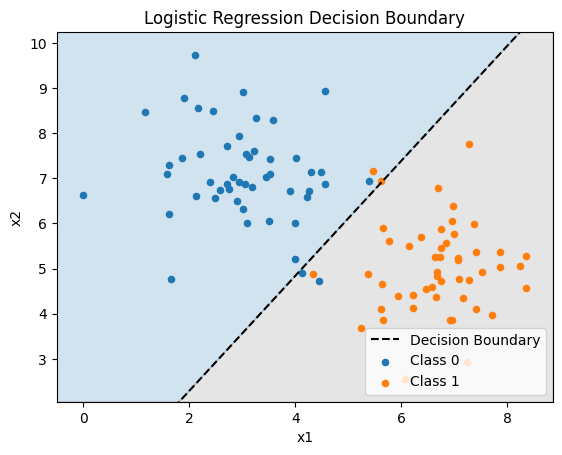

In [137]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

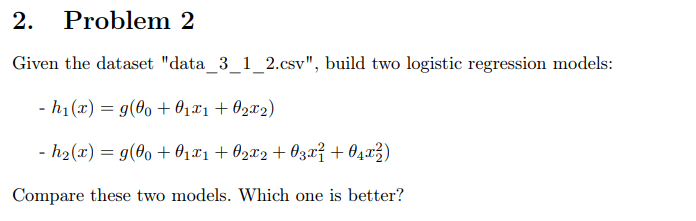

In [138]:
df_2 = pd.read_csv('data_3_1_2.csv')
df_2.head()

,x1,x2,class
0,9.076,3.721,0
1,6.809,3.930,0
2,8.256,2.851,1
3,8.461,3.145,1
4,6.783,3.188,1


In [139]:
df_2.shape

(200, 3)

In [140]:
X_train_1 = df_2[['x1', 'x2']].values
y_train = df_2['class'].values

X_temp = df_2[['x1', 'x2']].copy()

X_temp['x1_squared'] = X_temp['x1'] ** 2
X_temp['x2_squared'] = X_temp['x2'] ** 2

X_train_2 = X_temp.values

m, n = X_train_1.shape
print("Shape of X_train_1:", X_train_1.shape)
print("Shape of X_train_2:", X_train_2.shape)
print(f"Number of training examples: {m}")

Shape of X_train_1: (200, 2)
Shape of X_train_2: (200, 4)
Number of training examples: 200


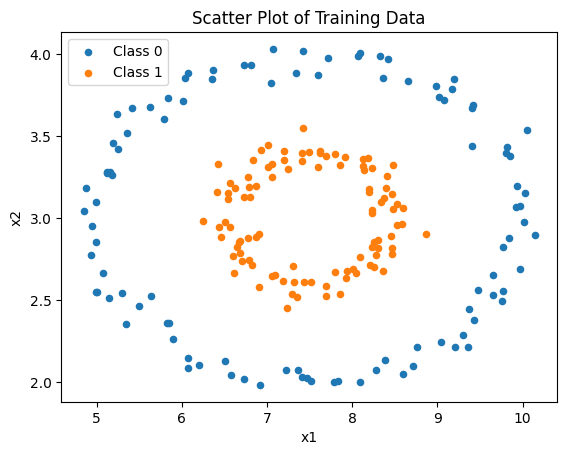

In [141]:
plt.scatter(X_train_1[y_train == 0, 0], X_train_1[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_1[y_train == 1, 0], X_train_1[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of Training Data')
plt.legend()
plt.show()

In [142]:
learning_rate = 0.01
num_iterations = 10000

final_w, final_b = gradient_descent(X_train_1, y_train, learning_rate, num_iterations)

predictions = predict(X_train_1, final_w, final_b)
predictions.shape
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931461066112753
Iteration 100: Cost 0.6931386916275203
Iteration 200: Cost 0.693134482976727
Iteration 300: Cost 0.6931310068772206
Iteration 400: Cost 0.693128100577815
Iteration 500: Cost 0.693125637833666
Iteration 600: Cost 0.6931235207150737
Iteration 700: Cost 0.6931216732541025
Iteration 800: Cost 0.6931200365167489
Iteration 900: Cost 0.6931185647808282
Iteration 1000: Cost 0.6931172225714994
Iteration 1100: Cost 0.6931159823619799
Iteration 1200: Cost 0.6931148227902059
Iteration 1300: Cost 0.6931137272756456
Iteration 1400: Cost 0.6931126829464985
Iteration 1500: Cost 0.6931116798076071
Iteration 1600: Cost 0.6931107100950821
Iteration 1700: Cost 0.6931097677757392
Iteration 1800: Cost 0.6931088481588554
Iteration 1900: Cost 0.6931079475950377
Iteration 2000: Cost 0.6931070632426578
Iteration 2100: Cost 0.6931061928866961
Iteration 2200: Cost 0.6931053347982322
Iteration 2300: Cost 0.6931044876254616
Iteration 2400: Cost 0.6931036503091598
Iteration 2500:

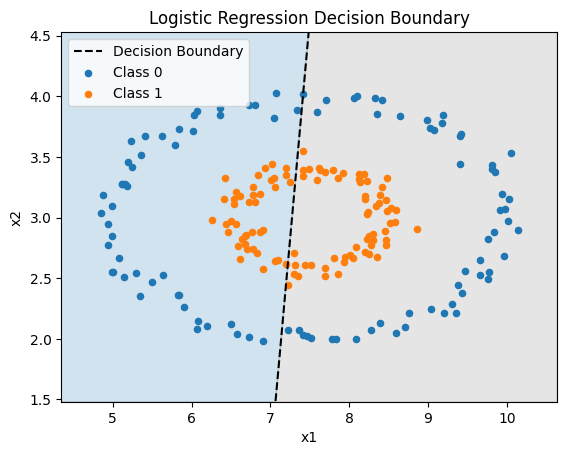

In [143]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train_1[:, 0].min() - 0.5, X_train_1[:, 0].max() + 0.5
ymin, ymax = X_train_1[:, 1].min() - 0.5, X_train_1[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_train_1[y_train == 0, 0], X_train_1[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_1[y_train == 1, 0], X_train_1[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [144]:
get_confusion_matrix(y_train,predictions)

([[46, 54], [41, 59]], [np.int64(0), np.int64(1)])

In [145]:
learning_rate = 0.01
num_iterations = 10000
# Simple Z-score normalization
X_scaled = (X_train_2 - np.mean(X_train_2, axis=0)) / np.std(X_train_2, axis=0)
final_w, final_b = gradient_descent(X_scaled, y_train, learning_rate, num_iterations)
predictions = predict(X_scaled, final_w, final_b)
accuracy = np.mean(predictions == y_train) * 100
print(f"Training Accuracy: {accuracy:.2f}%")

Iteration 0: Cost 0.6931323536697832
Iteration 100: Cost 0.6918141826338885
Iteration 200: Cost 0.6906737326531635
Iteration 300: Cost 0.6896003602482746
Iteration 400: Cost 0.6885531965162636
Iteration 500: Cost 0.687517135567937
Iteration 600: Cost 0.6864865888171612
Iteration 700: Cost 0.6854594858485242
Iteration 800: Cost 0.6844350574673904
Iteration 900: Cost 0.6834130159249938
Iteration 1000: Cost 0.6823932516498619
Iteration 1100: Cost 0.6813757210231222
Iteration 1200: Cost 0.6803604048420714
Iteration 1300: Cost 0.6793472929451722
Iteration 1400: Cost 0.6783363785206733
Iteration 1500: Cost 0.6773276559998584
Iteration 1600: Cost 0.6763211202772937
Iteration 1700: Cost 0.6753167664222808
Iteration 1800: Cost 0.674314589572133
Iteration 1900: Cost 0.673314584892741
Iteration 2000: Cost 0.6723167475640266
Iteration 2100: Cost 0.6713210727746085
Iteration 2200: Cost 0.6703275557198591
Iteration 2300: Cost 0.6693361916012204
Iteration 2400: Cost 0.6683469756259801
Iteration 2500:

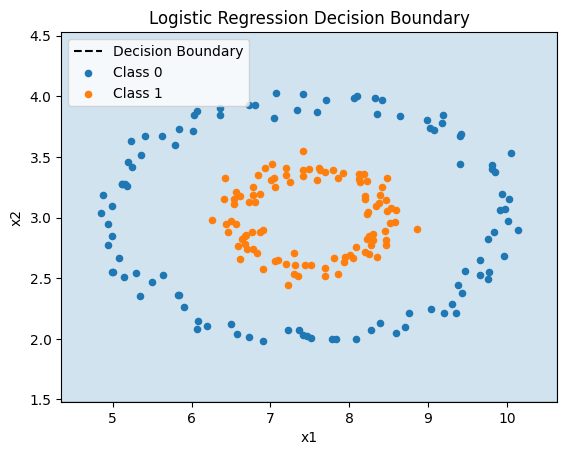

In [ ]:
slope = -final_w[0] / final_w[1]
intercept = -final_b / final_w[1]

xmin, xmax = X_train_2[:, 0].min() - 0.5, X_train_2[:, 0].max() + 0.5
ymin, ymax = X_train_2[:, 1].min() - 0.5, X_train_2[:, 1].max() + 0.5

xd = np.array([xmin, xmax])
yd = slope * xd + intercept

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:gray', alpha=0.2)
plt.fill_between(xd, yd, ymax,color='tab:blue', alpha=0.2)

plt.scatter(X_train_2[y_train == 0, 0], X_train_2[y_train == 0, 1], c='tab:blue', label='Class 0', s = 20)
plt.scatter(X_train_2[y_train == 1, 0], X_train_2[y_train == 1, 1], c='tab:orange', label='Class 1', s = 20)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()

In [ ]:
final_w

array([ 1.53313569,  1.48200905, -1.56888842, -1.53104136])

In [ ]:
get_confusion_matrix(y_train,predictions)

([[100, 0], [0, 100]], [np.int64(0), np.int64(1)])

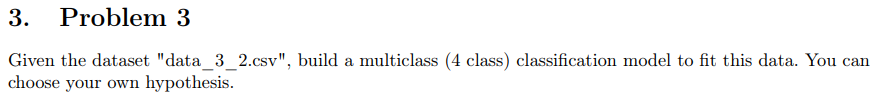

In [ ]:
data = pd.read_csv('data_3_2.csv')
data.head()

,x1,x2,class
0,10.52,0.65,3
1,1.46,-1.25,2
2,1.50,0.56,2
3,-1.36,2.50,0
4,11.16,5.19,1


In [ ]:
X = data[['x1', 'x2']].values
y = data['class'].values

classes = np.unique(y)
num_classes = len(classes)
print(f"Unique classes: {classes}")

Unique classes: [0 1 2 3]


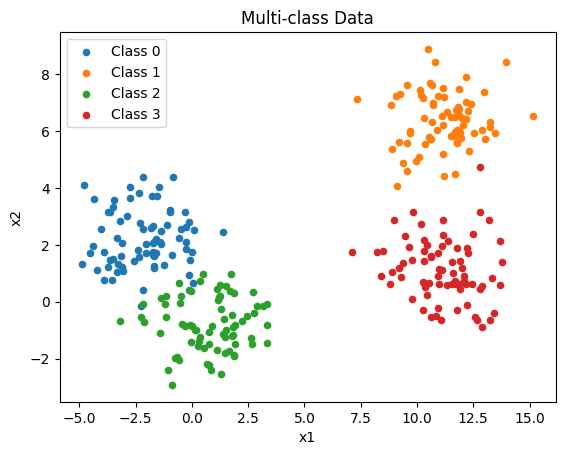

In [ ]:
for c in classes:
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multi-class Data')
plt.legend()
plt.show()


In [ ]:
#sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cost function
def cost_function(X, y, w, b):
    m = X.shape[0]
    epsilon = 1e-15
    cost = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)
        g = np.clip(g, epsilon, 1 - epsilon)

        cost += -y[i]*np.log(g) - (1-y[i])*np.log(1-g)

    return cost / m

#gradient function
def gradient_function(X, y, w, b):
    m, n = X.shape
    grad_w = np.zeros(n)
    grad_b = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        g = sigmoid(z)

        grad_b += (g - y[i])
        for j in range(n):
            grad_w[j] += (g - y[i]) * X[i][j]

    return grad_w/m, grad_b/m

#gradient descent function
def gradient_descent(X, y, alpha, iterations):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for it in range(iterations):
        grad_w, grad_b = gradient_function(X, y, w, b)

        w -= alpha * grad_w
        b -= alpha * grad_b

    return w, b

In [ ]:
def predict_prob(X, w, b):
    m = X.shape[0]
    probs = np.zeros(m)

    for i in range(m):
        z = np.dot(w, X[i]) + b
        probs[i] = sigmoid(z)

    return probs

In [ ]:
weights = []
biases = []

for c in classes:
    print(f"Training classifier for class {c}")

    # Create binary labels
    y_binary = (y == c).astype(int)

    w, b = gradient_descent(X, y_binary, alpha=0.1, iterations=1000)

    weights.append(w)
    biases.append(b)

weights = np.array(weights)
biases = np.array(biases)

Training classifier for class 0
Training classifier for class 1
Training classifier for class 2
Training classifier for class 3


In [ ]:
#predict multiclass
def predict_multiclass(X, weights, biases):
    m = X.shape[0]
    num_classes = weights.shape[0]
    probs = np.zeros((m, num_classes))

    for c in range(num_classes):
        probs[:, c] = predict_prob(X, weights[c], biases[c])

    return np.argmax(probs, axis=1)

In [ ]:
predictions = predict_multiclass(X, weights, biases)

accuracy = np.mean(predictions == y) * 100
print(f"\nMulticlass Accuracy: {accuracy:.2f}%")


Multiclass Accuracy: 98.33%


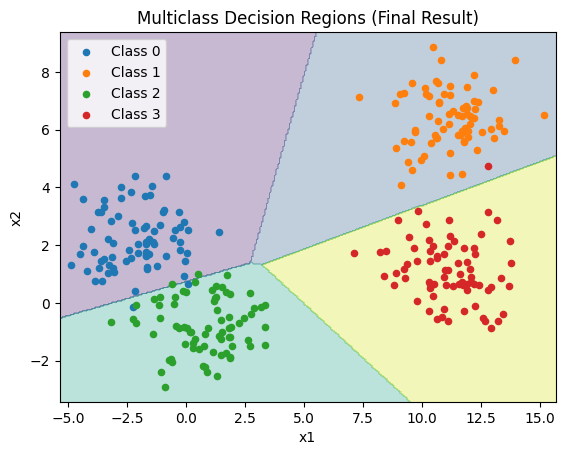

In [ ]:
# Plot decision regions 
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict class for each grid point
Z = predict_multiclass(grid, weights, biases)
Z = Z.reshape(xx1.shape)

# Plot decision regions
plt.contourf(xx1, xx2, Z, alpha=0.3)

# Plot actual data points
for c in classes:
    plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Class {c}', s=20)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Multiclass Decision Regions (Final Result)')
plt.legend()
plt.show()

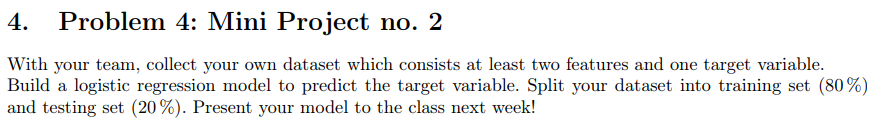